<a href="https://colab.research.google.com/github/yaletidevendra/Predictive-Maintenance/blob/main/Predictive_Maintenance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
#Devendra babu KY

Predictive Maintenance for NASA Turbofan Engines
1. Problem Overview

In aviation, engine reliability is critical. Maintenance is typically done in two ways:

Reactive maintenance: Fixing components after failure, which can be risky and expensive
Scheduled maintenance: Replacing parts at fixed intervals, even if they are still usable

A more efficient approach is to use sensor data to estimate when an engine is likely to fail. This allows maintenance to be performed only when needed.

Objective:
Estimate the Remaining Useful Life (RUL) of turbofan engines using sensor data.

2. Dataset (NASA CMAPSS – FD001)
Input: Time-series data from 21 sensors (e.g., temperature, pressure, speed)
Scenario: Engines operate normally at first, then gradually degrade until failure
Target: Remaining Useful Life (RUL), measured in cycles
3. Methodology
A. Data Cleaning and Feature Selection

Some sensors showed little to no variation and did not contribute useful information.

Removed 7 sensors with constant or near-constant values
Retained sensors that showed changes over time and reflected degradation

This reduced noise and simplified the dataset.

B. RUL Adjustment

Engines do not degrade immediately; they operate normally before wear becomes noticeable.

Applied an upper limit of 125 cycles to RUL values
This focuses the model on the period where degradation is more evident


C. Modeling

Tested several regression models:

Linear Regression,

Support Vector Regression (SVR),

Random Forest,

XGBoost.

Result:

XGBoost produced the best performance by modeling non-linear relationships between sensor data and engine degradation.

In [16]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

!git clone https://github.com/yaletidevendra/Predictive-Maintenance.git



fatal: destination path 'Predictive-Maintenance' already exists and is not an empty directory.


In [17]:
!ls Predictive-Maintenance	sample_data

# Define Column Names
index_names = ['unit_number', 'time_cycles']
operational_settings = ['setting_1', 'setting_2', 'setting_3']
# Grouping sensors helps in readability (Physical meanings)
sensor_names = [
    'T2', 'T24', 'T30', 'T50', 'P2', 'P15', 'P30',        # Temperatures & Pressures
    'Nf', 'Nc', 'epr', 'Ps30', 'phi', 'NRf', 'NRc',       # Rotational Speeds
    'BPR', 'farB', 'htBleed', 'Nf_dmd', 'PCNfR_dmd', 'W31', 'W32' # Others
]
col_names = index_names + operational_settings + sensor_names
print(f"Column names defined. Total columns: {len(col_names)}")


train_df = pd.read_csv("Predictive-Maintenance/train_FD001.txt", sep=r"\s+", header=None,names=col_names)
test_df = pd.read_csv("Predictive-Maintenance/test_FD001.txt", sep=r"\s+", header=None,names=col_names)
rul_df = pd.read_csv("Predictive-Maintenance/RUL_FD001.txt", sep=r"\s+", header=None,names=col_names)
train_df.head()



Predictive-Maintenance:
'Damage Propagation Modeling.pdf'   readme.txt
 data				    RUL_FD001.txt
'Main code'			    test_FD001.txt
 Predictive_Maintenance.ipynb	    train_FD001.txt

sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md
Column names defined. Total columns: 26


,unit_number,time_cycles,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [18]:
# Dimensionality Check
print(f'Training Data Shape: {train_df.shape}')
print(f'Testing Data Shape:  {test_df.shape}')
print(f'RUL File Shape:      {rul_df.shape}')

# Check the ratio of testing data
print(f"Percentage of Testing Data: {len(test_df)/(len(train_df)+len(test_df)):.2%}")

Training Data Shape: (20631, 26)
Testing Data Shape:  (13096, 26)
RUL File Shape:      (100, 26)
Percentage of Testing Data: 38.83%


In [19]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
T2,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
T24,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
T30,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
T50,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
P2,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


A. Identifying Constant Sensors

Some sensors do not change over time and therefore do not provide useful information.

Initial approach: Identify constant sensors using standard deviation (std = 0)
Issue: Due to numerical precision, values that are effectively constant can still produce very small non-zero standard deviations
Solution: Count the number of unique values instead

If a sensor has only one unique value, it is treated as constant and removed. This method is more reliable than checking standard deviation.

B. Target Preparation (RUL)

Remaining Useful Life (RUL) is calculated for each engine cycle.

An upper limit of 125 cycles is applied to RUL values
This reflects the period where the engine is operating normally before noticeable degradation begins

This adjustment helps the model focus on the later stages where changes in sensor readings are more meaningful.

In [20]:
constant_features = [col for col in train_df.columns if train_df[col].nunique() <= 1]

print(f'Dead/Constant Sensors identified: {constant_features}')
print(f'Number of Dead Sensors: {len(constant_features)} sensors.')

train_df.drop(columns=constant_features, inplace=True)
test_df.drop(columns=constant_features, inplace=True)

print("\nDropped constant columns successfully.")
print(f"New Training Shape: {train_df.shape}")

Dead/Constant Sensors identified: ['setting_3', 'T2', 'P2', 'epr', 'farB', 'Nf_dmd', 'PCNfR_dmd']
Number of Dead Sensors: 7 sensors.

Dropped constant columns successfully.
New Training Shape: (20631, 19)


Constructing the Target (RUL)

The dataset includes the total lifetime of each engine, but the goal is to estimate how much useful life remains at any given cycle.

The Remaining Useful Life (RUL) can be computed as:

RUL(t) = Tmax - t

In [21]:
# RUL Calculation
def calculate_rul(data, unit_col='unit_number', cycle_col='time_cycles'):
    max_cycle = (
        data.groupby(unit_col)[cycle_col].max()
        .reset_index().rename(columns={cycle_col: 'max_of_unit'})
    )
    data = data.merge(max_cycle, on=unit_col, how='left')
    data['RUL'] = data['max_of_unit'] - data[cycle_col]
    data.drop('max_of_unit', axis=1, inplace=True)
    return data


# Apply to your training data
train_df = calculate_rul(train_df)

# Preview result
train_df[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


Preprocessing & Modeling

Many machine learning models (such as Linear Regression, SVR, and Neural Networks) are affected by the scale of input features.

Issue:
Different sensors can have very different value ranges. For example, one sensor may vary between 1000–2000, while another ranges from 10–20. This can cause the model to give more importance to features with larger values.

Approach:
MinMax scaling is used to normalize all features into the range [0, 1], ensuring that each feature contributes more evenly.

In [22]:
# Select features to scale
features_to_normalize = [col for col in train_df.columns if col not in ['unit_number', 'time_cycles', 'RUL']]

scaler = MinMaxScaler()

train_df[features_to_normalize] = scaler.fit_transform(train_df[features_to_normalize])
test_df[features_to_normalize] = scaler.transform(test_df[features_to_normalize])

print("\nScaling completed successfully.")
print(f"Features Scaled: {len(features_to_normalize)}")

print("Data Scaling Completed (Range 0-1).")
print('-' * 30 + '\nData Preview after Scaling (Train) :\n')

display(train_df.head())


Scaling completed successfully.
Features Scaled: 17
Data Scaling Completed (Range 0-1).
------------------------------
Data Preview after Scaling (Train) :



,unit_number,time_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,RUL
0,1,1,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191
1,1,2,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190
2,1,3,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189
3,1,4,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188
4,1,5,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187


Model & Evaluation Metrics

XGBoost is a gradient boosting algorithm that performs well on structured data and can capture complex relationships between features.

Evaluation Metrics:

RMSE (Root Mean Squared Error):
Measures the average prediction error in terms of engine cycles.
For example, an RMSE of 20 means predictions are off by about 20 cycles on average.
R² Score:
Indicates how well the model explains the variation in Remaining Useful Life (RUL).

In [23]:
# Prepare training data
X_train = train_df[features_to_normalize]
y_train = train_df['RUL']

# We need to predict RUL at the LAST observed time cycle for each unit in the test set.
X_test_last_cycle = test_df.groupby('unit_number').last().reset_index()
X_test = X_test_last_cycle[features_to_normalize]

rul_df = pd.read_csv( "Predictive-Maintenance/RUL_FD001.txt", sep=r"\s+", header=None, names=['RUL'] )
y_true = rul_df['RUL']

print(f"Training Data: X={X_train.shape}, y={y_train.shape}")
print(f"Testing Data:  X={X_test.shape},  y={y_true.shape}")

Training Data: X=(20631, 17), y=(20631,)
Testing Data:  X=(100, 17),  y=(100,)


--- XGBoost Results ---
RMSE: 34.19
R2 Score: 32.29%


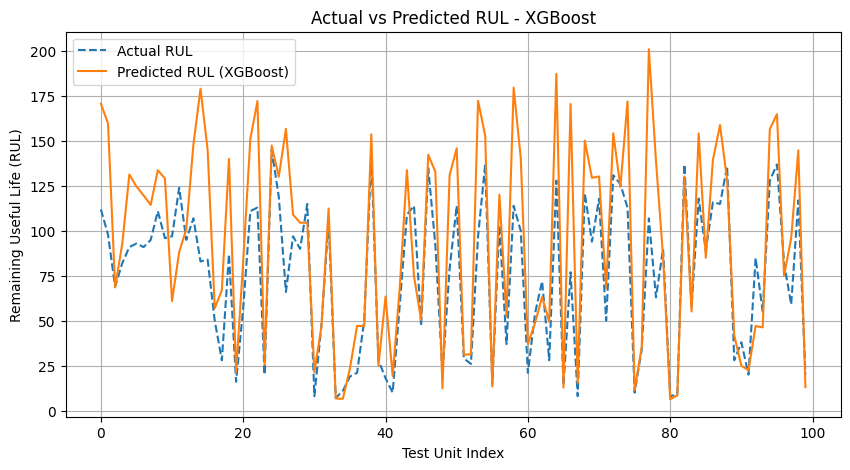

In [24]:
results_summary= []

def evaluate(model, X_train, y_train, X_test, y_true, model_name):
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  r2 = r2_score(y_true, y_pred)
    # Store results
  results_summary.append({
        'Model': model_name,
        'RMSE': rmse,
        'R2 Score': r2
    })

    # Print summary
  print(f"--- {model_name} Results ---")
  print(f"RMSE: {rmse:.2f}")
  print(f"R2 Score: {r2:.2%}")

    # Plot actual vs predicted
  plt.figure(figsize=(10, 5))
  plt.plot(y_true.values, label='Actual RUL', linestyle='--')
  plt.plot(y_pred, label=f'Predicted RUL ({model_name})')
  plt.xlabel('Test Unit Index')
  plt.ylabel('Remaining Useful Life (RUL)')
  plt.title(f'Actual vs Predicted RUL - {model_name}')
  plt.legend()
  plt.grid(True)
  plt.show()



  return y_pred

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

_ = evaluate(xgb_model, X_train, y_train, X_test, y_true, "XGBoost")

In [25]:
import joblib
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']

In [26]:
model = joblib.load("xgb_model.pkl")
y_pred = model.predict(New_engine_data)

In [27]:
print(y_pred)

[180.53133  157.53136  170.65837  ...  26.876205  21.386967  13.019866]
